In [1]:
import os
os.chdir('/home/jovyan/signal-extraction') # set the current working directory to the base signal-extraction folder so vae and sim files and easily be called.

In [2]:
from vae_code.chat_gam_gnll_VAE import *

# Implementing the MIMO-AE

### Loading the reanalysis data

In [3]:
import xarray as xr

In [4]:
sdata1 = xr.open_dataset("./vae_input_data/sst_mon-mean.nc")
pdata1 = xr.open_dataset("./vae_input_data/tp_mon-sum.nc")

In [4]:
print(f"{pdata1}, /n {sdata1}")

<xarray.Dataset> Size: 1MB
Dimensions:          (valid_time: 1026, bnds: 2, latitude: 17, longitude: 17)
Coordinates:
  * valid_time       (valid_time) datetime64[ns] 8kB 1940-01-16 ... 2025-06-1...
  * latitude         (latitude) float64 136B 40.0 39.75 39.5 ... 36.5 36.25 36.0
  * longitude        (longitude) float64 136B -123.0 -122.8 ... -119.2 -119.0
Dimensions without coordinates: bnds
Data variables:
    valid_time_bnds  (valid_time, bnds) datetime64[ns] 16kB ...
    tp               (valid_time, latitude, longitude) float32 1MB ...
Attributes:
    CDI:                     Climate Data Interface version 2.5.1 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Thu Jul 24 18:32:56 2025: CDO monsum ../signal-e...
    frequency:               mon
    CDO:         

### Running the VAE

In [5]:
m1 = learn(sdata1,pdata1,"minmax",'sst','tp', 0.5, 1, 0.8, 32)

Epoch 1/100 | Total: 2.1405 | SST (GNLL): -0.2373 | Precip (Gamma NLL): 2.3748 | KL: 0.0030
Epoch 2/100 | Total: 1.6234 | SST (GNLL): -0.5251 | Precip (Gamma NLL): 2.1431 | KL: 0.0054
Epoch 3/100 | Total: 1.0470 | SST (GNLL): -0.9551 | Precip (Gamma NLL): 1.9930 | KL: 0.0092
Epoch 4/100 | Total: 1.0981 | SST (GNLL): -0.9387 | Precip (Gamma NLL): 2.0284 | KL: 0.0085
Epoch 5/100 | Total: 1.0647 | SST (GNLL): -0.9587 | Precip (Gamma NLL): 2.0175 | KL: 0.0059
Epoch 6/100 | Total: 1.0866 | SST (GNLL): -0.9454 | Precip (Gamma NLL): 2.0276 | KL: 0.0044
Epoch 7/100 | Total: 0.9418 | SST (GNLL): -1.0510 | Precip (Gamma NLL): 1.9890 | KL: 0.0038
Epoch 8/100 | Total: 1.0325 | SST (GNLL): -0.9860 | Precip (Gamma NLL): 2.0155 | KL: 0.0030
Epoch 9/100 | Total: 0.9865 | SST (GNLL): -1.0269 | Precip (Gamma NLL): 2.0109 | KL: 0.0025
Epoch 10/100 | Total: 0.9787 | SST (GNLL): -1.0307 | Precip (Gamma NLL): 2.0077 | KL: 0.0017
Epoch 11/100 | Total: 1.0202 | SST (GNLL): -0.9981 | Precip (Gamma NLL): 2.0158

In [6]:
train_summary(m1,'./results/chat_gam_VAE_s05r1_training_summary')

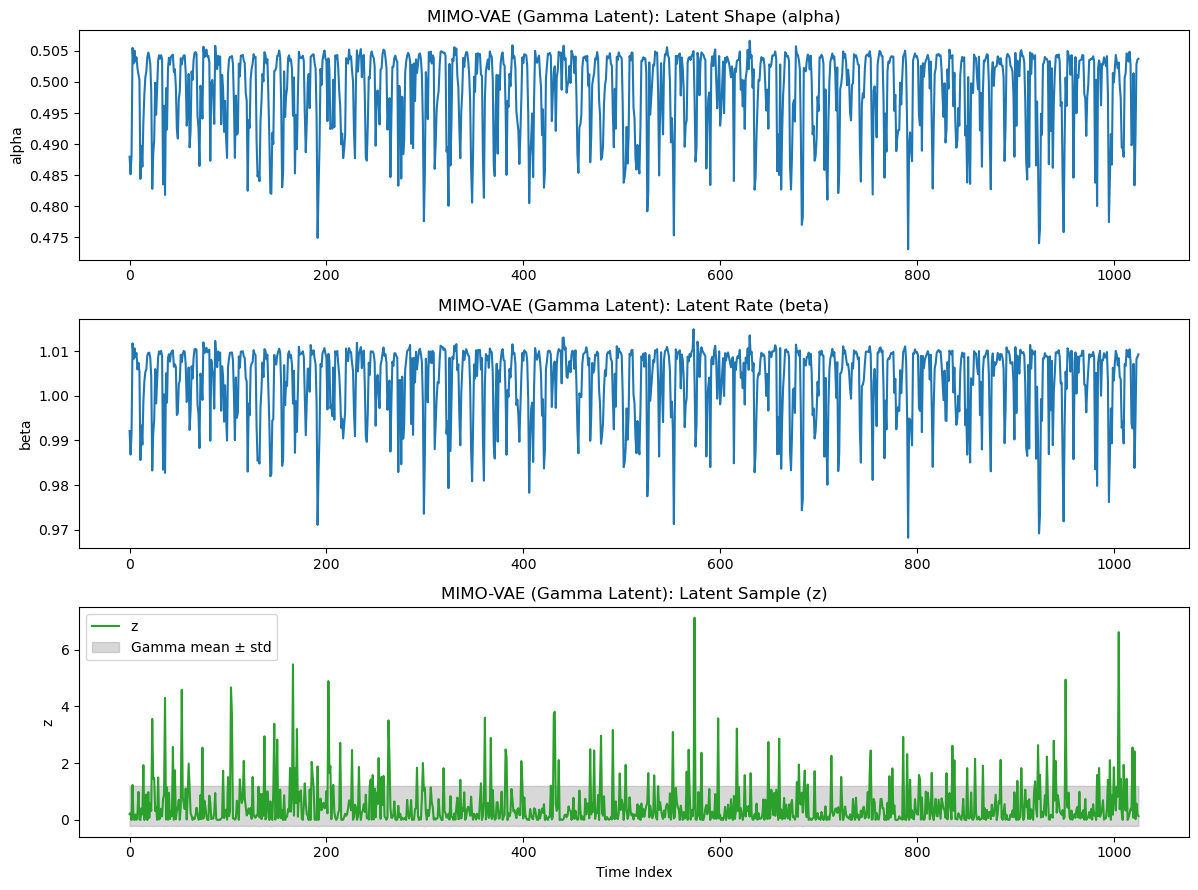

In [7]:
e1 = extractr(m1['model'],sdata1,'sst',pdata1,'tp',m1['sst_scaler'],m1['precip_scaler'],True,True,"./results/gam_gnll/gam_gnll_extractr_results")

In [8]:
from vae_code.plotter import *

In [9]:
gam_gnll_latent = pd.read_csv('~/signal-extraction/results/gam_gnll/gam_gnll_extractr_results_latent_full.csv')

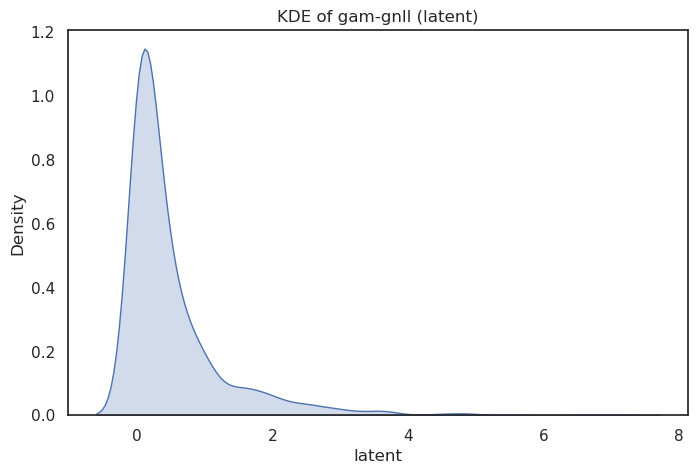

In [10]:
universalKDE('latent', 'gam-gnll',gam_gnll_latent['latent'])

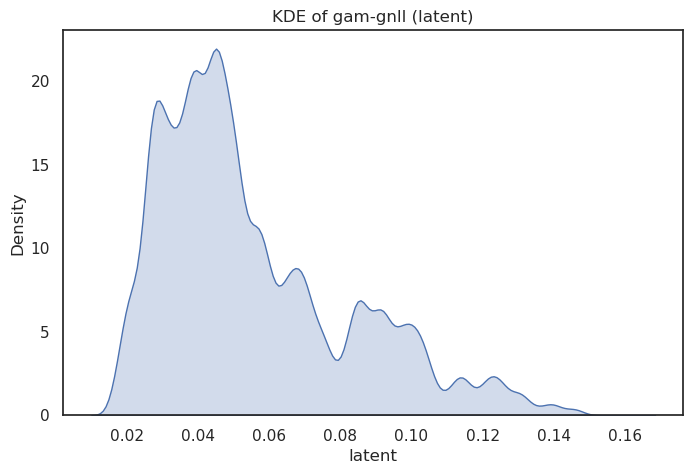

In [11]:
recon_pr = xr.open_dataset('~/signal-extraction/results/gam_gnll/gam_gnll_extractr_results_precip.nc')

universalKDE('latent', 'gam-gnll',recon_pr['precip'])

In [ ]:
from simulator_code.Wavelet import *

In [17]:
# Load
signal = gam_gnll_latent

# --- Choose which latent variable to process ---
latent_var = 'latent'   # or "lambda", "alpha", "beta", etc.
time_var = 'time'

# Ensure datetime index (and sorted)
signal[time_var] = pd.to_datetime(signal[time_var], errors='coerce')
signal = signal.set_index(time_var).sort_index()

# Make sure latent_var column is numeric
signal[latent_var] = pd.to_numeric(signal[latent_var], errors='coerce')

# --- Shift to ensure positivity ---
latent_min = signal[latent_var].min()
if latent_min <= 0:
    eps = 1e-6  # nominal epsilon for numerical stability
    shift_value = -latent_min + eps
    signal[latent_var] = signal[latent_var] + shift_value
    print(f"Shifted '{latent_var}' upward by {shift_value:.6f} to ensure positivity.")

# Signal date window
sig_start = signal.index.min()
sig_end   = signal.index.max()

# Annual means of the latent variable
latent_annual_max = signal[latent_var].resample('YE').mean()

# Years (from the index, not the values)
latent_years = signal.index.year
latent_time = np.unique(latent_years)

# Series of annual mean values
latent_time_series = latent_annual_max.values


In [18]:
siglvl_wave = 0.95
sigtest = 'default'

In [19]:
# wavelet transform
#warnings.filterwarnings('ignore', 'divide by zero encountered in divide', RuntimeWarning)
wlt = wavelet(latent_time_series)
Cw = CI(wlt, latent_time_series, siglvl_wave, "r")
C = CI(wlt, latent_time_series, siglvl_wave, "w")

# Global Wavelet Spectrum
plt_dataset = {
    'Time': latent_time,
    'Period': wlt['period'],
    'Avg_Power': wlt['avg_power'],
    'Power': wlt['power'],
    'COI': wlt['coi'],
    'W_noise': C['sig'],
    'R_noise': Cw['sig']
}

Red Noise AR1 Coefficient: 0.6980830862766753


/home/jovyan/signal-extraction/simulator_code/Wavelet.py:50: RuntimeWarning: divide by zero encountered in divide
  expnt = -(scl * k - param) ** 2 / (2 * (k > 0))


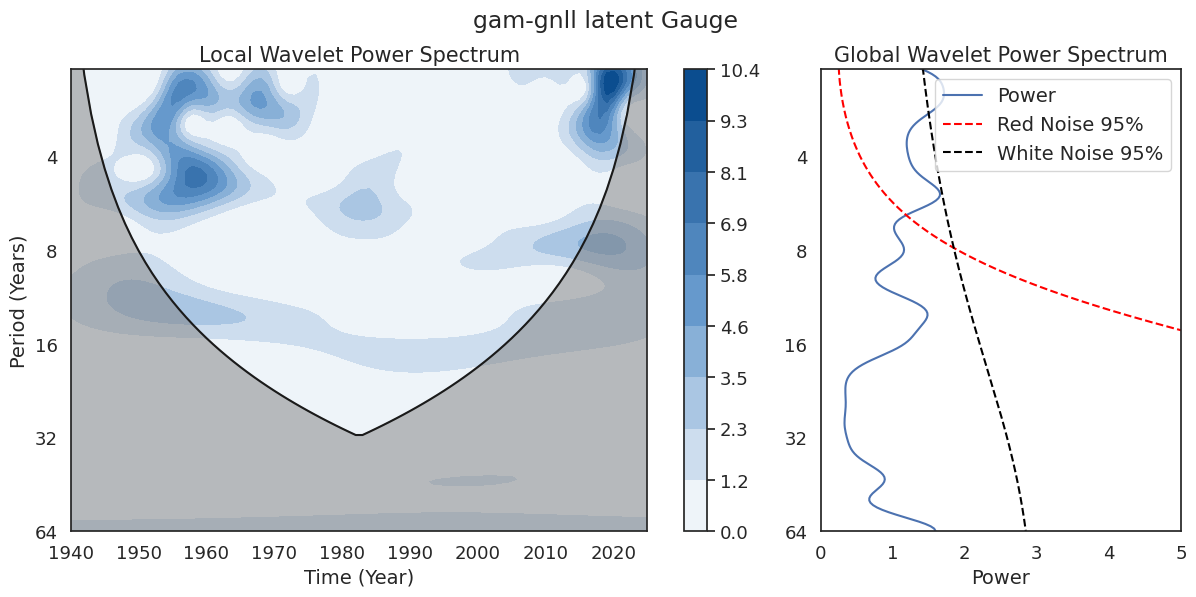

In [20]:
wavelet_plot(plt_dataset, siglvl_wave, 'gam-gnll latent', sigtest)